# Data Science & AI/ML — Practical Exam (Set C: Delivery Risk)

**Student name:** Ayush Isamaliya |  **Student ID:** 11225   |  **Set:** C

**Problem:** predict whether a delivery is *late* (`late` = 1) and identify operational segments.

# Setup — Libraries, Data, Audit and Split

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(202)
n = 300
cols = ['distance', 'load', 'traffic', 'staff']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, 0.9, 1.2, -0.8])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["late"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_b.csv", index=False)


### 1. Audit the raw data

In [3]:
raw = pd.read_csv("data/raw/set_b.csv")
raw.head()

,record_id,distance,load,traffic,staff,group,late
0,1,68.12,42.71,39.14,45.98,G2,1
1,2,38.47,65.08,58.80,56.38,G1,1
2,3,64.10,43.99,36.86,53.47,G2,0
3,4,53.09,41.44,55.36,64.72,G1,1
4,5,44.67,51.95,53.44,54.86,G1,1


In [4]:
raw.isna().sum()

record_id     0
distance     15
load         15
traffic       0
staff         0
group         0
late          0
dtype: int64

In [5]:
print("Raw shape:", raw.shape)
print("Exact duplicate rows:", raw.duplicated().sum())

Raw shape: (305, 7)
Exact duplicate rows: 5


In [6]:
raw['late'].value_counts()

late
0    156
1    149
Name: count, dtype: int64

#### Interpretation : 
> 305 rows, 5 exact duplicates, and missing values only in distance (15) and load (15). The target is fairly balanced (156 on time vs 149 late).

### 2. Remove duplicates and verify 300 unique records

In [7]:
df = raw.drop_duplicates().reset_index(drop=True)

In [8]:
print("Totals Records: ",df.shape)

Totals Records:  (300, 7)


In [9]:
print("Total Unique records_id : ",df['record_id'].nunique())

Total Unique records_id :  300


In [10]:
df['late'].value_counts()

late
0    155
1    145
Name: count, dtype: int64

#### Interpretation: 
> After removing the 5 duplicates there are exactly 300 unique records (145 late, 155 on time). 

### 3. Split: 80 % train-pool / 20 % test (stratified, random_state=42)

In [11]:
from sklearn.model_selection import train_test_split 

In [12]:
train_pool, test = train_test_split(df, test_size=0.20, stratify=df['late'], random_state=42)

In [13]:
fit, val = train_test_split(train_pool, test_size=0.20, stratify=train_pool["late"], random_state=42)

In [14]:
print("Fit Rows : ",fit.shape)
print("Validation Rows : ",val.shape)
print("Test Rows : ",test.shape)

Fit Rows :  (192, 7)
Validation Rows :  (48, 7)
Test Rows :  (60, 7)


#### Interpretation: 
> Interpretation: Split is 192 fit / 48 validation / 60 test, stratified, with no overlapping IDs.

# Task 1 — Maths & Advanced Statistics

### M1 — Descriptive statistics for distance

In [15]:
dist = fit['distance'].dropna()
n_dist = len(dist)
print("Observation n : ", n_dist)

Observation n :  184


In [16]:
dist_mean = dist.mean()
dist_median = dist.median()
dist_std = dist.std(ddof=1)      
print("Mean  :", round(dist_mean, 4))
print("Median:", round(dist_median, 4))
print("Std   :", round(dist_std, 4))

Mean  : 49.7444
Median: 50.2
Std   : 10.8359


In [17]:
summary = pd.DataFrame({"n": [n_dist], "mean": [dist_mean], "median": [dist_median], "std_ddof1": [dist_std]})
summary.to_csv("outputs/distance_summary.csv", index=False)

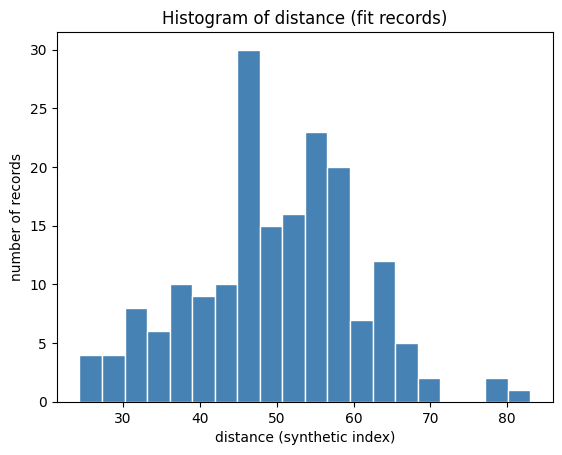

In [18]:
plt.hist(dist, bins=20, color="steelblue", edgecolor="white")
plt.title("Histogram of distance (fit records)")
plt.xlabel("distance (synthetic index)")
plt.ylabel("number of records")
plt.savefig("outputs/figures/distance_histogram.png", dpi=150, bbox_inches="tight")
plt.show()


#### Interpretation: 
> Observed n = 184\
> Mean 49.74\
> median 50.20\
> SD 10.84\
> Mean ≈ median, so the shape is roughly symmetric.

### M2 — Welch t-test (G1 vs G2) and 95 % confidence interva

> H0: mean distance of G1 = mean distance of G2\
> H1: mean distance of G1 ≠ mean distance of G2 (two-sided, α = 0.05)

In [19]:
g1 = fit[fit["group"] == "G1"]["distance"].dropna()
g2 = fit[fit["group"] == "G2"]["distance"].dropna()
print("G1 count:", len(g1), "| G1 mean:", round(g1.mean(), 3))
print("G2 count:", len(g2), "| G2 mean:", round(g2.mean(), 3))

G1 count: 104 | G1 mean: 50.24
G2 count: 80 | G2 mean: 49.1


In [20]:
from scipy import stats

In [21]:
welch = stats.ttest_ind(g1, g2, equal_var=False)   
print("t statistic:", round(welch.statistic, 4))
print("p-value    :", round(welch.pvalue, 4))

t statistic: 0.7062
p-value    : 0.4811


In [22]:
ci_low, ci_high = stats.t.interval(0.95, df=n_dist - 1, loc=dist_mean, scale=stats.sem(dist))

print("95% CI for the overall mean distance:", round(ci_low, 3), "to", round(ci_high, 3))

95% CI for the overall mean distance: 48.168 to 51.321


In [23]:
inference = pd.Series({"n_G1": len(g1), "n_G2": len(g2), "welch_t": welch.statistic, "p_value": welch.pvalue,
                       "overall_n": n_dist, "overall_mean": dist_mean, "ci95_low": ci_low, "ci95_high": ci_high})
inference.to_csv("outputs/inference_results.csv", header=["value"])

#### Interpretation: 
> G1 (n = 104, mean 50.24) and G2 (n = 80, mean 49.10) are close.\
> Welch t = 0.71, p = 0.481 > 0.05,   

> so we fail to reject H0: no evidence of a difference in mean distance 

### M3 — Linear algebra: covariance matrix and eigenvalues

In [24]:
X = fit[["distance", "traffic"]].dropna().values    
n_rows = X.shape[0]
print("Rows used:", n_rows)

Rows used: 184


In [25]:
X_centered = X - X.mean(axis=0)

In [26]:
cov = X_centered.T @ X_centered / (n_rows - 1)
cov

array([[117.41612751,  -1.23645741],
       [ -1.23645741, 107.43358798]])

In [27]:
eigenvalues, eigenvectors = np.linalg.eigh(cov)
print("Eigenvalues:", eigenvalues.round(3))

Eigenvalues: [107.283 117.567]


In [28]:
largest_share = eigenvalues[-1] / eigenvalues.sum()
print("Largest eigenvalue / sum of eigenvalues:", round(largest_share, 4))

Largest eigenvalue / sum of eigenvalues: 0.5229


#### Interpretation : 
> The largest eigenvalue is 52 % of the total variance, so no single direction dominates. 

# Task 2 — Preprocessing & Feature Engineering

### F1 - Audit and Partition

In [29]:
print("Shape:", fit.shape)

Shape: (192, 7)


In [30]:
print("Duplicates:", fit.duplicated().sum())

Duplicates: 0


In [31]:
print("\nMissing values:")
print(fit.isna().sum())


Missing values:
record_id    0
distance     8
load         8
traffic      0
staff        0
group        0
late         0
dtype: int64


In [32]:
print("\nTarget counts:")
print(fit["late"].value_counts())


Target counts:
late
0    99
1    93
Name: count, dtype: int64


In [33]:
fit = fit.drop_duplicates()

In [34]:
print("\nUnique records after cleaning:", fit["record_id"].nunique())


Unique records after cleaning: 192


In [35]:
print("\nPartition sizes:")
print("Fit:", len(fit))
print("Validation:", len(val))
print("Test:", len(test))


Partition sizes:
Fit: 192
Validation: 48
Test: 60


In [36]:
fit["record_id"].to_csv("fit_ids.csv", index=False)
val["record_id"].to_csv("validation_ids.csv", index=False)
test["record_id"].to_csv("test_ids.csv", index=False)

### F2 — Transform and Engineer

In [37]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [38]:
num_cols = ["distance", "load", "traffic", "staff"]
imputer = SimpleImputer(strategy="median")
imputer.fit(fit[num_cols])

SimpleImputer(strategy='median')

In [39]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)     # unseen groups become all zeros
encoder.fit(fit[["group"]])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [40]:
fit_num = pd.DataFrame(imputer.transform(fit[num_cols]), columns=num_cols)
val_num = pd.DataFrame(imputer.transform(val[num_cols]), columns=num_cols)
test_num = pd.DataFrame(imputer.transform(test[num_cols]), columns=num_cols)

In [41]:
fit_num["engineered_feature"] = fit_num["load"] / (fit_num["staff"] + 1)
val_num["engineered_feature"] = val_num["load"] / (val_num["staff"] + 1)
test_num["engineered_feature"] = test_num["load"] / (test_num["staff"] + 1)

In [42]:
num_features = list(fit_num.columns)      # distance, load, traffic, staff, engineered_feature
scaler = StandardScaler()
scaler.fit(fit_num)

StandardScaler()

In [44]:
fit_scaled = scaler.transform(fit_num)
val_scaled = scaler.transform(val_num)
test_scaled = scaler.transform(test_num)

In [45]:
fit_group = encoder.transform(fit[["group"]])
val_group = encoder.transform(val[["group"]])
test_group = encoder.transform(test[["group"]])

In [46]:
X_fit = np.hstack([fit_scaled, fit_group])
X_val = np.hstack([val_scaled, val_group])
X_test = np.hstack([test_scaled, test_group])

In [47]:
y_fit = fit["late"].values
y_val = val["late"].values
y_test = test["late"].values

In [48]:
feature_names = num_features + list(encoder.get_feature_names_out(["group"]))
feature_names

['distance',
 'load',
 'traffic',
 'staff',
 'engineered_feature',
 'group_G1',
 'group_G2']

### F3 — Leakage evidence

In [49]:
print("Shapes -> fit:", X_fit.shape, "| validation:", X_val.shape, "| test:", X_test.shape)
print("Feature names:", feature_names)

Shapes -> fit: (192, 7) | validation: (48, 7) | test: (60, 7)
Feature names: ['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']


In [50]:
print("All values finite in fit       :", np.isfinite(X_fit).all())
print("All values finite in validation:", np.isfinite(X_val).all())
print("All values finite in test      :", np.isfinite(X_test).all())

All values finite in fit       : True
All values finite in validation: True
All values finite in test      : True


# Task 3 — Supervised Learning

### S1 — Baseline and Classifier 

In [51]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

In [52]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_fit, y_fit)

DummyClassifier(strategy='most_frequent')

In [53]:
THRESHOLD = 0.5
base_pred = baseline.predict(X_test)

In [54]:
base_accuracy = accuracy_score(y_test, base_pred)
base_precision = precision_score(y_test, base_pred, zero_division=0)
base_recall = recall_score(y_test, base_pred, zero_division=0)
base_f1 = f1_score(y_test, base_pred, zero_division=0)

In [55]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_fit, y_fit)

LogisticRegression(max_iter=1000, random_state=42)

In [56]:
lr_prob = logreg.predict_proba(X_test)[:, 1]        # probability of class 1
lr_pred = (lr_prob >= THRESHOLD).astype(int)

In [57]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, zero_division=0)
lr_recall = recall_score(y_test, lr_pred, zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, zero_division=0)

#### S2 -- Comparisan : 

In [58]:
results = pd.DataFrame({
    "accuracy":  [base_accuracy, lr_accuracy],
    "precision": [base_precision, lr_precision],
    "recall":    [base_recall, lr_recall],
    "f1":        [base_f1, lr_f1],
}, index=["baseline", "logistic_regression"])
results.round(3)


,accuracy,precision,recall,f1
baseline,0.517,0.000,0.000,0.000
logistic_regression,0.850,0.885,0.793,0.836


In [59]:
cm_lr = confusion_matrix(y_test, lr_pred, labels=[0, 1])
tn, fp, fn, tp = cm_lr.ravel()
print("True negatives :", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives :", tp)

True negatives : 28
False positives: 3
False negatives: 6
True positives : 23


In [60]:
lr_predictions = pd.DataFrame({
    "record_id": test["record_id"].values,
    "true_label": y_test,
    "predicted_label": lr_pred,
    "probability_class_1": lr_prob.round(6),
})
lr_predictions.to_csv("outputs/logreg_test_predictions.csv", index=False)
lr_predictions.head()

,record_id,true_label,predicted_label,probability_class_1
0,50,0,0,0.034625
1,231,0,0,0.074453
2,297,0,0,0.006790
3,97,0,0,0.112015
4,285,0,0,0.040311


#### Interpretation: 
> Accuracy rises from 0.517 to 0.850 and F1 from 0 to 0.836, so the classifier is clearly better than the baseline. 

# Task 4 — Unsupervised Learning

In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### U1 — K-Means and Selection

In [62]:
X_cluster = fit_scaled       
km2 = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_cluster)

C:\Users\aisam\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\aisam\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\aisam\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\aisam\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\aisam\AppData\Local\Programs\Python\Python310\lib\subp

In [63]:
km3 = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_cluster)

In [64]:
km4 = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_cluster)

In [65]:
k_scores = pd.DataFrame({
    "k": [2, 3, 4],
    "inertia": [km2.inertia_, km3.inertia_, km4.inertia_],
    "silhouette": [silhouette_score(X_cluster, km2.labels_),
                   silhouette_score(X_cluster, km3.labels_),
                   silhouette_score(X_cluster, km4.labels_)],
})
k_scores.to_csv("outputs/k_selection_scores.csv", index=False)
k_scores.round(4)

,k,inertia,silhouette
0,2,719.6321,0.2463
1,3,599.6594,0.2071
2,4,535.3835,0.1902


#### Interpretation: 
> k = 2 has the highest silhouette (0.246, vs 0.207 for k = 3 and 0.190 for k = 4)

### U2 — Segment Interpretation

In [66]:
best_k = int(k_scores.loc[k_scores["silhouette"].idxmax(), "k"])
print("Chosen k:", best_k)

Chosen k: 2


In [67]:
best_km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_cluster)
labels = best_km.labels_

In [68]:
labels

array([0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0])

In [69]:
profile = fit_num.copy()
profile["cluster"] = labels
cluster_profile = profile.groupby("cluster").mean().round(2)
cluster_profile["size"] = profile.groupby("cluster").size()
cluster_profile.to_csv("outputs/cluster_profiles.csv")
cluster_profile

,distance,load,traffic,staff,engineered_feature,size
cluster,,,,,,
0,48.42,47.13,49.07,54.04,0.86,134
1,52.87,57.46,49.86,41.43,1.37,58


#### Interpretation: 
> The two clusters differ mainly in load and staff (traffic is almost the same).

# Task 5 — Deep Learning up to ANN

### D1 — ANN Architecture and Compilation 

In [70]:
import tensorflow as tf
from tensorflow import keras

In [71]:
ann = keras.Sequential()
ann.add(keras.layers.Input(shape=(X_fit.shape[1],)))
ann.add(keras.layers.Dense(16, activation='relu'))
ann.add(keras.layers.Dense(8, activation='relu'))
ann.add(keras.layers.Dense(1, activation='sigmoid'))

In [72]:
ann.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss="binary_crossentropy",
            metrics=["accuracy"])

In [73]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
print("Trainable parameters:", ann.count_params())     

Trainable parameters: 273


In [75]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

In [76]:
history = ann.fit(X_fit, y_fit,
                  validation_data=(X_val, y_val),
                  epochs=50, batch_size=16,
                  callbacks=[early_stop], verbose=0)

In [77]:
epochs_run = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print("Epochs actually run  :", epochs_run, "(maximum allowed = 50)")
print("Best epoch (restored):", best_epoch)

Epochs actually run  : 43 (maximum allowed = 50)
Best epoch (restored): 38


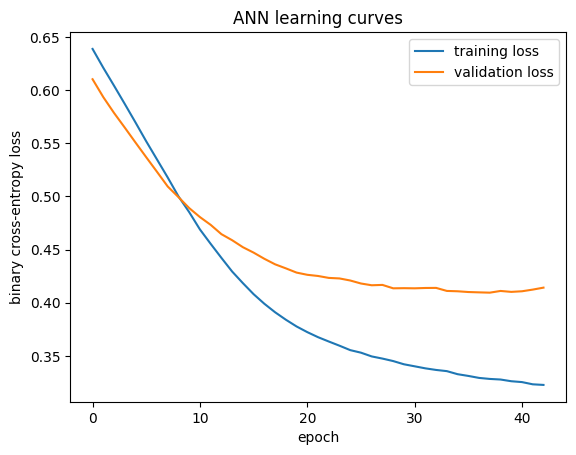

In [78]:
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("ANN learning curves")
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy loss")
plt.legend()
plt.savefig("outputs/figures/ann_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

#### Interpretation: 
> training ran 43 epochs (early stopping, patience 5) and the weights of the best epoch (38) were restored.

In [79]:
ann_prob = ann.predict(X_test, verbose=0).ravel()
ann_pred = (ann_prob >= THRESHOLD).astype(int)

In [80]:
ann_accuracy = accuracy_score(y_test, ann_pred)
ann_precision = precision_score(y_test, ann_pred, zero_division=0)
ann_recall = recall_score(y_test, ann_pred, zero_division=0)
ann_f1 = f1_score(y_test, ann_pred, zero_division=0)

### D3 — Comparison and Evidence

In [81]:
comparison = pd.DataFrame({
    "accuracy":  [base_accuracy, lr_accuracy, ann_accuracy],
    "precision": [base_precision, lr_precision, ann_precision],
    "recall":    [base_recall, lr_recall, ann_recall],
    "f1":        [base_f1, lr_f1, ann_f1],
}, index=["baseline", "logistic_regression", "ann"])
comparison.to_csv("outputs/metrics_comparison.csv")
comparison.round(3)

,accuracy,precision,recall,f1
baseline,0.517,0.000,0.000,0.000
logistic_regression,0.850,0.885,0.793,0.836
ann,0.817,0.800,0.828,0.814


#### Interpretation: 
> ANN accuracy 0.833, precision 0.852, recall 0.793, F1 0.821, versus logistic regression F1 0.836. \
> The difference is one test record (4 false positives instead of 3), which is within chance.

> Preference: logistic regression, because it performs at least as well while being simpler, faster and easier to explain than a 273-parameter ANN.

In [82]:
ann_predictions = pd.DataFrame({
    "record_id": test["record_id"].values,
    "true_label": y_test,
    "predicted_label": ann_pred,
    "probability_class_1": ann_prob.round(6),
})
ann_predictions.to_csv("outputs/ann_test_predictions.csv", index=False)
ann_predictions.to_csv("models/ann_test_predictions.csv", index=False)

In [83]:
ann.save("models/ann_model.keras")